<a href="https://colab.research.google.com/github/PALAK7890/Credit_Risk_Predictor/blob/main/P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

In [83]:
url='https://raw.githubusercontent.com/PALAK7890/Credit_Risk_Predictor/refs/heads/main/loan_default_large.csv'
df=pd.read_csv(url)
df.head(15)

,customer_id,age,gender,education,employment_type,employment_years,annual_income,loan_amount,debt_to_income_ratio,credit_score,num_previous_loans,missed_payments_last_2yr,defaulted
0,CUST_00621,66.0,F,PhD,salaried,0.0,22359.0,80038,0.42,304.0,8,5,0
1,CUST_04385,69.0,NaN,High School,Self-Employed,11.0,11480.0,46060,0.37,689.0,6,11,0
2,CUST_06794,51.0,NaN,high school,NaN,10.0,50334.0,77580,0.29,828.0,4,4,0
3,CUST_04562,54.0,NaN,NaN,self employed,12.0,78683.0,8234,0.43,810.0,2,6,1
4,CUST_09264,68.0,F,high school,Salaried,14.0,27420.0,30131,0.38,551.0,4,9,0
5,CUST_03132,41.0,Male,NaN,NaN,14.0,NaN,85141,0.68,542.0,1,13,1
6,CUST_08710,31.0,Male,BACHELOR,Self-Employed,13.0,18595.0,87334,NaN,447.0,1,5,1
7,CUST_05737,NaN,Male,Bachelor,NaN,NaN,-99999.0,42424,0.20,311.0,5,0,1
8,CUST_07782,35.0,Female,High School,Salaried,12.0,42667.0,20445,0.39,654.0,1,3,0
9,CUST_06503,41.0,Female,Master,NaN,29.0,46786.0,24476,0.36,372.0,1,5,1


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10150 entries, 0 to 10149
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10150 non-null  object 
 1   age                       9340 non-null   float64
 2   gender                    8703 non-null   object 
 3   education                 9002 non-null   object 
 4   employment_type           8683 non-null   object 
 5   employment_years          9339 non-null   float64
 6   annual_income             9339 non-null   float64
 7   loan_amount               10150 non-null  int64  
 8   debt_to_income_ratio      9342 non-null   float64
 9   credit_score              9345 non-null   float64
 10  num_previous_loans        10150 non-null  int64  
 11  missed_payments_last_2yr  10150 non-null  int64  
 12  defaulted                 10150 non-null  int64  
dtypes: float64(5), int64(4), object(4)
memory usage: 1.0+ MB


<Axes: >

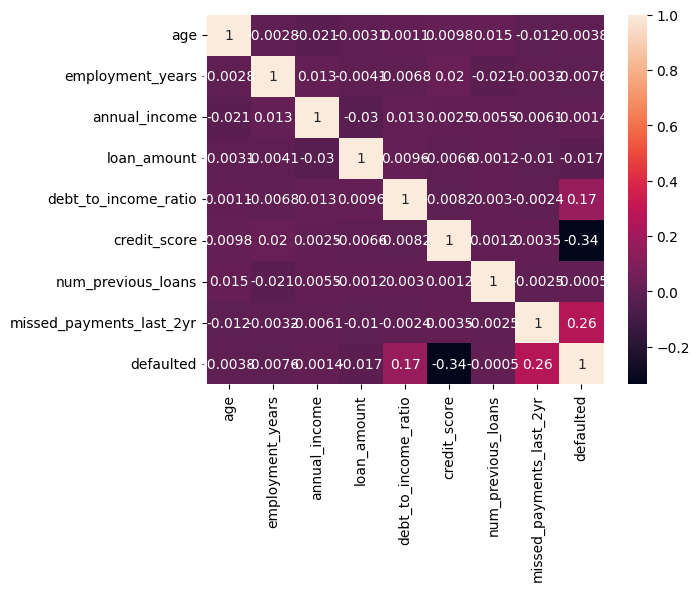

In [85]:
df_num=df.select_dtypes(include='number')
sns.heatmap(df_num.corr(),annot=True,)

In [86]:
df.duplicated().sum()

np.int64(150)

In [87]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [88]:
df['gender']=df['gender'].str.lower().str.strip().str[0]

df['education']=df['education'].str.lower().str.strip()
mapping = {
    'high school': 'High School',
    'bachelor': 'Bachelor',
    'master': 'Master',
    'masters': 'Master',
    'phd': 'PhD'
}

df['education'] = df['education'].map(mapping)
df['employment_type']=df['employment_type'].str.lower().str.strip()


In [89]:
df['defaulted'].value_counts(normalize=True)

,proportion
defaulted,
0,0.5562
1,0.4438


<Axes: >

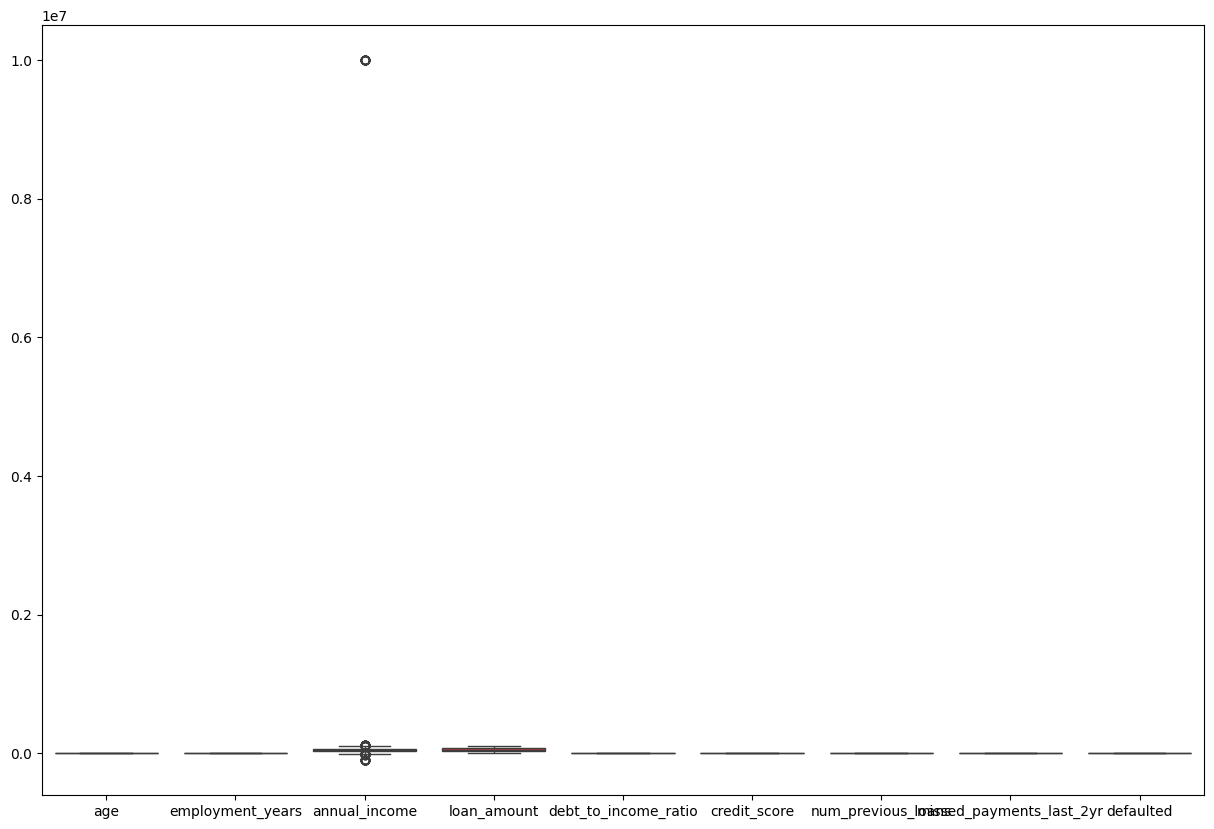

In [90]:
plt.figure(figsize=(15,10))
sns.boxplot(df_num)

In [91]:
df_num.isnull().sum()

,0
age,810
employment_years,811
annual_income,811
loan_amount,0
debt_to_income_ratio,808
credit_score,805
num_previous_loans,0
missed_payments_last_2yr,0
defaulted,0


In [92]:
Q1 = df['annual_income'].quantile(0.25)
Q3 = df['annual_income'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[df['annual_income'].between(lower, upper)]

In [93]:
df['age']=df['age'].fillna(df['age'].median())
df['employment_years']=df['employment_years'].fillna(df['employment_years'].median())
df['annual_income']=df['annual_income'].fillna(df['annual_income'].median())
df['debt_to_income_ratio']=df['debt_to_income_ratio'].fillna(df['debt_to_income_ratio'].median())
df['credit_score']=df['credit_score'].fillna(df['credit_score'].median())

In [94]:
df['gender']=df['gender'].fillna(df['gender'].mode()[0])
df['education']=df['education'].fillna(df['education'].mode()[0])
df['employment_type']=df['employment_type'].fillna(df['employment_type'].mode()[0])
df.drop('customer_id',inplace=True,axis=1)

In [107]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['High School', 'Bachelor', 'Master', 'PhD']])
df['education'] = oe.fit_transform(df[['education']])

df=pd.get_dummies(df,columns=['employment_type','gender'],drop_first=True)

ValueError: could not convert string to float: 'High School'

In [108]:
from sklearn.model_selection import train_test_split
X=df.drop('defaulted',axis=1)
y=df['defaulted']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [109]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(X_train)
x_test_scaled=sc.transform(X_test)

In [110]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(x_train_scaled,y_train)
pred_logistic=model.predict(x_test_scaled)

In [111]:
from sklearn.tree import DecisionTreeClassifier
model1=DecisionTreeClassifier(class_weight='balanced',random_state=42,max_depth=5)
model1.fit(x_train_scaled,y_train)
pred_tree=model1.predict(x_test_scaled)

In [112]:
from sklearn.ensemble import RandomForestClassifier
model_forest=RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42,max_depth=15,min_samples_leaf=5)
model_forest.fit(x_train_scaled,y_train)
pred_forest=model_forest.predict(x_test_scaled)


In [113]:
from sklearn.metrics import accuracy_score,roc_auc_score
acc_logistic=accuracy_score(y_test,pred_logistic)
roc_logistic=roc_auc_score(y_test,pred_logistic)
acc_logistic,roc_logistic

(0.6672167216721672, np.float64(0.6668498812769327))

In [114]:
acc_tree=accuracy_score(y_test,pred_tree)
roc_tree=roc_auc_score(y_test,pred_tree)
acc_tree,roc_tree

(0.7095709570957096, np.float64(0.7103926655527218))

In [115]:
acc_forest=accuracy_score(y_test,pred_forest)
roc_forest=roc_auc_score(y_test,pred_forest)
acc_forest,roc_forest

(0.7007700770077008, np.float64(0.6958784041274587))

In [116]:
from sklearn.metrics import classification_report

print("--- Logistic Regression ---")
print(classification_report(y_test, pred_logistic))

print("--- Decision Tree ---")
print(classification_report(y_test, pred_tree))

print("--- Random Forest ---")
print(classification_report(y_test, pred_forest))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.71      0.67      0.69       996
           1       0.62      0.66      0.64       822

    accuracy                           0.67      1818
   macro avg       0.67      0.67      0.67      1818
weighted avg       0.67      0.67      0.67      1818

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.75      0.70      0.73       996
           1       0.67      0.72      0.69       822

    accuracy                           0.71      1818
   macro avg       0.71      0.71      0.71      1818
weighted avg       0.71      0.71      0.71      1818

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.72      0.75      0.73       996
           1       0.68      0.64      0.66       822

    accuracy                           0.70      1818
   macro avg       0.70      0.70      0.70      1818
we